In [1]:
import klampt
import pickle
import numpy as np
import cv2
import ast
import matplotlib.pyplot as plt
from icecream import ic
from tqdm import tqdm
from check_zarr_data import read_zarr_folder

ic| 

data[0]['wrist_img'].shape: (1, 2, 3, 480, 640)
ic| img.dtype: dtype('float32')
ic| img.shape: (3, 480, 640)
ic| np.mean(img): 0.6787218
ic| np.var(img): 0.1126302
ic| data[0]['wrist_img'].shape: (1, 2, 3, 480, 640)
ic| img.dtype: dtype('float32')
ic| img.shape: (3, 480, 640)
ic| np.mean(img): 0.68052244
ic| np.var(img): 0.112617925


Range of values in img: min=0.01568627543747425, max=1.0
Range of values in img: min=0.01568627543747425, max=1.0


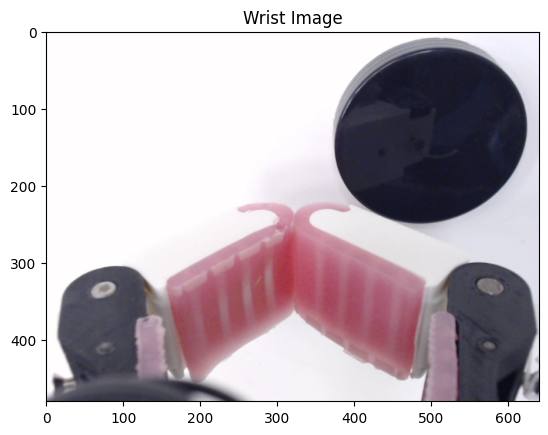

In [25]:
data_index = 12
# real_world

with open(f'rollout_data/obs_dict_list_{data_index}.pkl', 'rb') as file:
    data = pickle.load(file)

for i in range(2):
    img = data[2]['wrist_img'][0, i]
    ic(data[0]['wrist_img'].shape)
    ic(img.dtype)
    ic(img.shape)
    ic(np.mean(img))
    ic(np.var(img))
    print(f"Range of values in img: min={np.min(img)}, max={np.max(img)}")
    # ic(img)
img = img.astype(np.float32)
img = img[[2, 1, 0], :, :]  # Flip RGB to BGR
plt.imshow(img.transpose(1, 2, 0))
plt.title('Wrist Image')
plt.show()


ic| img2.shape: (3, 480, 640)
ic| np.mean(img2): 0.8222626
ic| np.var(img2): 0.067856394
ic| np.max(img2): 1.0, np.min(img2): 0.023529053
ic| np.isnan(img2).any(): False
ic| img2.shape: (3, 480, 640)
ic| np.mean(img2): 0.82226264
ic| np.var(img2): 0.067856394
ic| np.max(img2): 1.0, np.min(img2): 0.023529053
ic| np.isnan(img2).any(): False


Range of values in img2: min=0.023529052734375, max=1.0
Range of values in img2: min=0.023529052734375, max=1.0


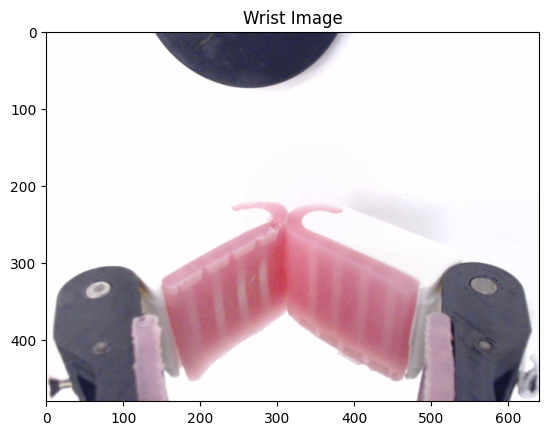

In [19]:
data_index = 11
# replay data

with open(f'rollout_data/obs_dict_list_{data_index}.pkl', 'rb') as file:
    data2 = pickle.load(file)
for i in range(2):
    img = data[0]['wrist_img'][0, i]
    ic(img2.shape)
    # ic(img)
    ic(np.mean(img2))
    img2 = img2.astype(np.float32)
    ic(np.var(img2))
    ic(np.max(img2), np.min(img2))
    ic(np.isnan(img2).any())
    print(f"Range of values in img2: min={np.min(img2)}, max={np.max(img2)}")
    img2 = img2.astype(np.float32)
    img2 = img2[[2, 1, 0], :, :]  # Flip RGB to BGR
plt.imshow(img2.transpose(1, 2, 0))
plt.title('Wrist Image')
plt.show()

In [2]:
video_path = 'dummy.avi'  # Replace with your video file name

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video.")
else:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imshow('Video', frame)
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

: 